In [1]:
# Célula 1: Carregar Dados Processados para Análise (D2)

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns # Para gráficos mais elaborados posteriormente

print("--- Iniciando Notebook 02: Análise de Dados ---")
print(f"Data da execução: {pd.Timestamp.now()}") # Registra a data da execução

# --- Configurações de Plotagem (Opcional, mas recomendado para consistência) ---
# Você pode descomentar e ajustar conforme sua preferência
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams['figure.figsize'] = (14, 7) # Tamanho padrão um pouco maior para análise
# plt.rcParams['figure.dpi'] = 90
# sns.set_theme(style="whitegrid")

# --- Definição dos Caminhos para os Dados Curados ---
# Ajuste o caminho base se o seu notebook não estiver na raiz do projeto 'combap25'
# Se o notebook estiver em 'A:\Projetos\combap25\notebooks\02_data_analysis.ipynb',
# o caminho para 'data' seria '../data/'
# Se o notebook estiver na raiz 'A:\Projetos\combap25\02_data_analysis.ipynb',
# o caminho para 'data' seria 'data/'

# Tenta definir o caminho base do projeto de forma mais robusta
# Se este notebook estiver na pasta 'notebooks', sobe um nível.
# Caso contrário, assume que está na raiz do projeto.
try:
    if Path.cwd().name == "notebooks": # Verifica se o diretório atual é 'notebooks'
        BASE_PROJECT_DIR = Path.cwd().parent
    else:
        BASE_PROJECT_DIR = Path.cwd() # Assume que está na raiz do projeto
except Exception:
    BASE_PROJECT_DIR = Path(".") # Fallback para diretório atual

CURATED_DATA_DIR = BASE_PROJECT_DIR / "data" / "curated"
print(f"Diretório base do projeto inferido como: {BASE_PROJECT_DIR}")
print(f"Tentando carregar dados curados de: {CURATED_DATA_DIR}")

# DataFrames que serão carregados
full_df = pd.DataFrame()
stats_df = pd.DataFrame()

if not CURATED_DATA_DIR.exists():
    print(f"ERRO: Diretório de dados curados não encontrado: {CURATED_DATA_DIR}")
    print("Certifique-se de que o caminho está correto e que o D1 (processamento de dados) foi concluído.")
else:
    # Caminhos para os arquivos Parquet finais do D1
    path_full_df = CURATED_DATA_DIR / "telemetry_full.parquet" 
    path_stats_df = CURATED_DATA_DIR / "telemetry_stats.parquet"

    # --- Carregar telemetry_full.parquet ---
    if path_full_df.exists():
        print(f"\nCarregando DataFrame completo de telemetria: {path_full_df.name}")
        try:
            full_df = pd.read_parquet(path_full_df)
            print(f"  Shape de full_df: {full_df.shape}")
            print(f"  Colunas em full_df: {full_df.columns.tolist()}")
            # print("  Tipos de dados em full_df:\n", full_df.dtypes.to_string()) # Mais detalhado
            
            # Verificação crucial para 'timestamp'
            if 'timestamp' in full_df.columns:
                if full_df['timestamp'].isnull().all():
                    print("  ALERTA CRÍTICO: Coluna 'timestamp' em full_df está TODA NULA!")
                elif pd.api.types.is_numeric_dtype(full_df['timestamp']):
                    print("  Coluna 'timestamp' em full_df é numérica (segundos) e parece OK.")
                else:
                    print(f"  AVISO: 'timestamp' em full_df NÃO é numérica (tipo: {full_df['timestamp'].dtype}). Pode precisar de conversão/verificação.")
            else:
                print("  ALERTA CRÍTICO: Coluna 'timestamp' não encontrada em full_df!")

            if 'source_file' not in full_df.columns:
                 print("  ALERTA: Coluna 'source_file' não encontrada em full_df.")
            
            print("  Amostra de full_df (primeiras 3 linhas):")
            print(full_df.head(3))
        except Exception as e:
            print(f"  ERRO ao carregar {path_full_df.name}: {e}")
    else:
        print(f"ERRO: Arquivo de telemetria completo não encontrado: {path_full_df}")

    # --- Carregar telemetry_stats.parquet ---
    if path_stats_df.exists():
        print(f"\nCarregando DataFrame de estatísticas agregadas: {path_stats_df.name}")
        try:
            stats_df = pd.read_parquet(path_stats_df)
            print(f"  Shape de stats_df: {stats_df.shape}")
            print(f"  Colunas em stats_df: {stats_df.columns.tolist()}")
            print("  Amostra de stats_df (primeiras 3 linhas):")
            print(stats_df.head(3))
        except Exception as e:
            print(f"  ERRO ao carregar {path_stats_df.name}: {e}")
    else:
        print(f"ERRO: Arquivo de estatísticas agregadas não encontrado: {path_stats_df}")

if full_df.empty:
    print("\nAVISO: DataFrame 'full_df' está vazio. Verifique os erros de carregamento.")
if stats_df.empty:
    print("AVISO: DataFrame 'stats_df' está vazio. Verifique os erros de carregamento.")

print("\n--- Célula 1 (Notebook 02) concluída ---")


--- Iniciando Notebook 02: Análise de Dados ---
Data da execução: 2025-05-15 10:11:47.798937
Diretório base do projeto inferido como: A:\Projetos\combap25
Tentando carregar dados curados de: A:\Projetos\combap25\data\curated

Carregando DataFrame completo de telemetria: telemetry_full.parquet
  Shape de full_df: (42961792, 7)
  Colunas em full_df: ['timestamp', 'fuel_rate', 'engine_rpm', 'veh_speed', 'source_file', 'tractor', 'activity']
  Coluna 'timestamp' em full_df é numérica (segundos) e parece OK.
  Amostra de full_df (primeiras 3 linhas):
   timestamp  fuel_rate  engine_rpm  veh_speed source_file    tractor activity
0        0.0        1.3       801.0        0.0   Fendt 211  Fendt 211    Geral
1        0.1        1.3       801.5        0.0   Fendt 211  Fendt 211    Geral
2        0.2        1.3       801.5        0.0   Fendt 211  Fendt 211    Geral

Carregando DataFrame de estatísticas agregadas: telemetry_stats.parquet
  Shape de stats_df: (33, 9)
  Colunas em stats_df: ['tract

--- Iniciando Célula 2: Análise de Tempo Ocioso (com novo limiar de velocidade) ---
Analisando 'full_df' com 42961792 linhas.

Critérios para Ocioso (ATUALIZADOS):
  - Velocidade <= 0.75 m/s
  - RPM Motor entre 700 e 1000 RPM
  - Taxa de Combustível > 0.1 L/h

Número de registros identificados como ociosos (com novo limiar): 6897844 (16.06% do total)

AVISO: Colunas 'delta_t_hours' ou 'liters_consumed' não encontradas em full_df.
Recalculando delta_t e liters_consumed (isso pode levar um momento)...
  Colunas 'delta_t_hours' e 'liters_consumed_interval' recalculadas.

Tempo total em ociosidade (com novo limiar): 245.53 horas
Combustível total consumido em ociosidade (com novo limiar): 747.25 litros

Agregando dados de ociosidade por trator e atividade (com novo limiar)...

Amostra de stats_df ATUALIZADO com informações de ociosidade (novo limiar):
     tractor               activity  total_hours_operational  idle_hours  \
0  Fendt 211                  Geral                46.323222   1

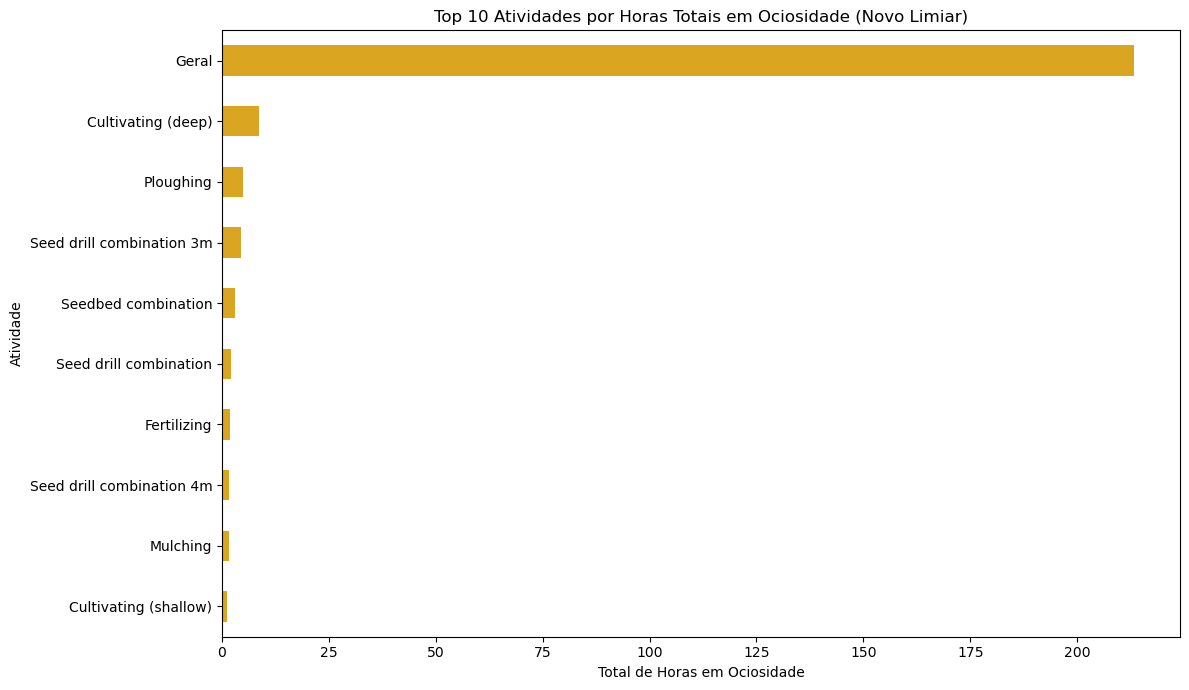

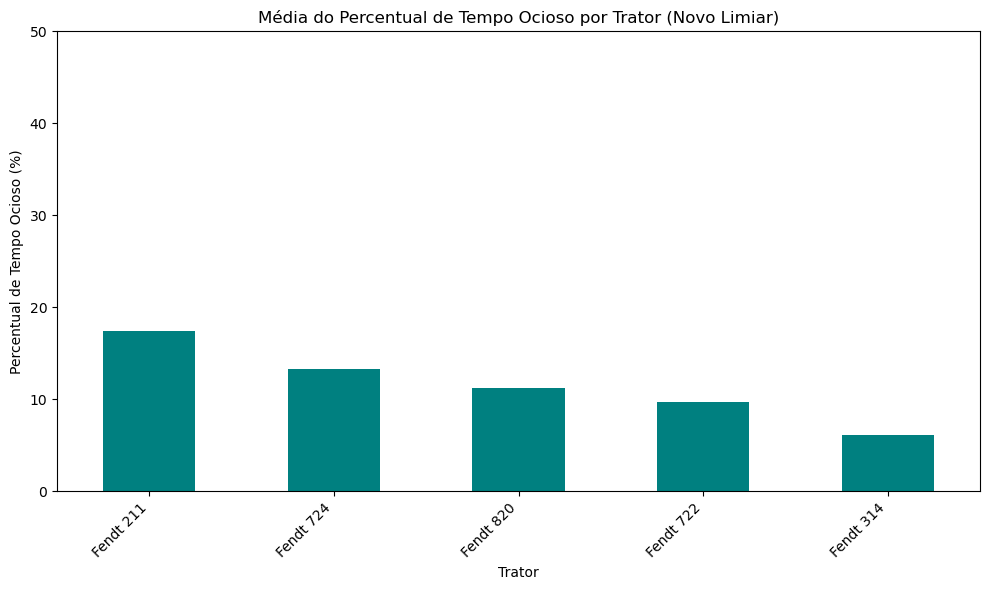


--- Célula 2 (com novo limiar de velocidade) concluída ---


In [16]:
# Célula 2: Análise de Tempo Ocioso (com novo limiar de velocidade)

# Certifique-se de que a Célula 1 foi executada e os DataFrames full_df e stats_df estão carregados.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# full_df, stats_df # Devem existir da célula anterior

print("--- Iniciando Célula 2: Análise de Tempo Ocioso (com novo limiar de velocidade) ---")

if 'full_df' not in locals() or full_df.empty:
    print("ERRO: DataFrame 'full_df' está vazio. Execute a Célula 1 primeiro para carregar os dados.")
else:
    print(f"Analisando 'full_df' com {full_df.shape[0]} linhas.")

    # --- 1. Definir Critérios para Tempo Ocioso ---
    # Ajustando o limiar de velocidade conforme solicitado
    VELOCIDADE_MAX_OCIOSO_MS = 0.75  # metros por segundo (aproximadamente 1 km/h)
    RPM_MIN_OCIOSO = 700
    RPM_MAX_OCIOSO = 1000 
    FUEL_RATE_MIN_OCIOSO_L_H = 0.1 

    print(f"\nCritérios para Ocioso (ATUALIZADOS):")
    print(f"  - Velocidade <= {VELOCIDADE_MAX_OCIOSO_MS} m/s")
    print(f"  - RPM Motor entre {RPM_MIN_OCIOSO} e {RPM_MAX_OCIOSO} RPM")
    print(f"  - Taxa de Combustível > {FUEL_RATE_MIN_OCIOSO_L_H} L/h")

    # Identificar linhas onde o trator está ocioso
    condicao_ocioso = (
        (full_df['veh_speed'].notna() & (full_df['veh_speed'] <= VELOCIDADE_MAX_OCIOSO_MS)) &
        (full_df['engine_rpm'].notna() & (full_df['engine_rpm'] >= RPM_MIN_OCIOSO) & (full_df['engine_rpm'] <= RPM_MAX_OCIOSO)) &
        (full_df['fuel_rate'].notna() & (full_df['fuel_rate'] > FUEL_RATE_MIN_OCIOSO_L_H))
    )
    
    full_df['is_idle'] = condicao_ocioso
    
    num_idle_records = full_df['is_idle'].sum()
    percent_idle_records = (num_idle_records / len(full_df)) * 100
    print(f"\nNúmero de registros identificados como ociosos (com novo limiar): {num_idle_records} ({percent_idle_records:.2f}% do total)")

    if num_idle_records == 0:
        print("Nenhum registro ocioso encontrado com os critérios atuais. Verifique os limiares ou os dados.")
    else:
        # --- 2. Calcular Duração e Consumo em Ociosidade ---
        coluna_litros_a_usar = ""
        coluna_delta_horas_a_usar = ""

        if 'delta_t_hours' not in full_df.columns or 'liters_consumed' not in full_df.columns:
            print("\nAVISO: Colunas 'delta_t_hours' ou 'liters_consumed' não encontradas em full_df.")
            print("Recalculando delta_t e liters_consumed (isso pode levar um momento)...")
            
            if 'source_file' not in full_df.columns:
                print("  ERRO CRÍTICO para recalcular: Coluna 'source_file' não encontrada em full_df.")
                print("  Os cálculos de ociosidade podem ser imprecisos sem 'source_file' para o diff correto.")
                # Adicionando colunas vazias para evitar que o código quebre, mas os resultados serão INCORRETOS.
                full_df['delta_t_hours'] = 0
                full_df['liters_consumed_interval'] = 0
                coluna_litros_a_usar = 'liters_consumed_interval'
                coluna_delta_horas_a_usar = 'delta_t_hours'

            else:
                full_df_sorted = full_df.sort_values(by=['tractor', 'activity', 'source_file', 'timestamp'])
                # Usar .copy() para evitar SettingWithCopyWarning se full_df for uma fatia
                full_df = full_df_sorted.copy()
                
                full_df['delta_t_seconds'] = full_df.groupby(['tractor', 'activity', 'source_file'], observed=True)['timestamp'].diff().fillna(0)
                
                max_reasonable_delta_t_seconds = 600 
                full_df.loc[full_df['delta_t_seconds'] < 0, 'delta_t_seconds'] = 0
                full_df.loc[full_df['delta_t_seconds'] > max_reasonable_delta_t_seconds, 'delta_t_seconds'] = 0 # Ou np.nan para excluir
                
                full_df['delta_t_hours'] = full_df['delta_t_seconds'] / 3600.0
                full_df['liters_consumed_interval'] = full_df['fuel_rate'] * full_df['delta_t_hours'] 
                full_df['liters_consumed_interval'] = full_df['liters_consumed_interval'].fillna(0)
                print("  Colunas 'delta_t_hours' e 'liters_consumed_interval' recalculadas.")
                coluna_litros_a_usar = 'liters_consumed_interval'
                coluna_delta_horas_a_usar = 'delta_t_hours'
        else:
            # Se as colunas já existem, vamos usá-las.
            # É importante que 'liters_consumed' represente o consumo NO INTERVALO 'delta_t_hours'.
            # Se 'liters_consumed' foi o nome da coluna de consumo instantâneo (L/h), isso estaria errado.
            # A Célula 10 do notebook anterior calculou 'liters_consumed' como (fuel_rate * delta_t_hours), o que está correto.
            # No entanto, para clareza e evitar confusão com a coluna 'fuel_rate',
            # é melhor usar um nome como 'liters_consumed_interval' se recalculado aqui.
            # Se 'liters_consumed' já é o consumo do intervalo, pode usar.
            # Vamos assumir que 'liters_consumed' e 'delta_t_hours' de full_df estão corretos se existirem.
            coluna_litros_a_usar = 'liters_consumed' 
            coluna_delta_horas_a_usar = 'delta_t_hours'
            print(f"Usando colunas existentes: '{coluna_delta_horas_a_usar}' e '{coluna_litros_a_usar}' para cálculos de ociosidade.")


        idle_df = full_df[full_df['is_idle']].copy()

        if idle_df.empty:
            print("DataFrame 'idle_df' está vazio após filtrar por 'is_idle'. Verifique os critérios.")
        else:
            total_idle_hours = idle_df[coluna_delta_horas_a_usar].sum()
            total_fuel_consumed_idle = idle_df[coluna_litros_a_usar].sum()

            print(f"\nTempo total em ociosidade (com novo limiar): {total_idle_hours:.2f} horas")
            print(f"Combustível total consumido em ociosidade (com novo limiar): {total_fuel_consumed_idle:.2f} litros")

            print("\nAgregando dados de ociosidade por trator e atividade (com novo limiar)...")
            idle_summary = idle_df.groupby(['tractor', 'activity'], observed=True).agg(
                idle_hours=pd.NamedAgg(column=coluna_delta_horas_a_usar, aggfunc='sum'),
                idle_fuel_liters=pd.NamedAgg(column=coluna_litros_a_usar, aggfunc='sum'),
                count_idle_periods=pd.NamedAgg(column='is_idle', aggfunc='count') 
            ).reset_index()

            if 'stats_df' not in locals() or stats_df.empty:
                print("AVISO: stats_df não está definido ou está vazio. Criando a partir de idle_summary.")
                stats_df = idle_summary # Se stats_df não existir, o resumo de ociosidade se torna a base
            else:
                # Remove colunas antigas de ociosidade de stats_df para evitar duplicação antes do merge
                cols_to_drop_from_stats = ['idle_hours', 'idle_fuel_liters', 'count_idle_periods', 'percent_idle_time', 'percent_fuel_idle', 'idle_cost_eur', 'idle_cost_per_idle_hour']
                stats_df = stats_df.drop(columns=[col for col in cols_to_drop_from_stats if col in stats_df.columns], errors='ignore')
                
                stats_df = pd.merge(stats_df, idle_summary, on=['tractor', 'activity'], how='left')
            
            stats_df[['idle_hours', 'idle_fuel_liters', 'count_idle_periods']] = stats_df[['idle_hours', 'idle_fuel_liters', 'count_idle_periods']].fillna(0)
            
            # Recalcular percentuais com os novos dados de ociosidade
            # Garante que 'total_hours_operational' e 'total_liters_consumed' existam e sejam numéricos
            if 'total_hours_operational' in stats_df.columns and pd.api.types.is_numeric_dtype(stats_df['total_hours_operational']):
                stats_df['percent_idle_time'] = stats_df.apply(lambda row: (row['idle_hours'] / row['total_hours_operational']) * 100 if row['total_hours_operational'] > 1e-6 else 0, axis=1)
            else:
                print("AVISO: 'total_hours_operational' ausente ou não numérico em stats_df. 'percent_idle_time' não pode ser calculado.")
                stats_df['percent_idle_time'] = 0

            if 'total_liters_consumed' in stats_df.columns and pd.api.types.is_numeric_dtype(stats_df['total_liters_consumed']):
                 stats_df['percent_fuel_idle'] = stats_df.apply(lambda row: (row['idle_fuel_liters'] / row['total_liters_consumed']) * 100 if row['total_liters_consumed'] > 1e-6 else 0, axis=1)
            else:
                print("AVISO: 'total_liters_consumed' ausente ou não numérico em stats_df. 'percent_fuel_idle' não pode ser calculado.")
                stats_df['percent_fuel_idle'] = 0
                
            stats_df[['percent_idle_time', 'percent_fuel_idle']] = stats_df[['percent_idle_time', 'percent_fuel_idle']].fillna(0)
            
            print("\nAmostra de stats_df ATUALIZADO com informações de ociosidade (novo limiar):")
            print(stats_df[['tractor', 'activity', 'total_hours_operational', 'idle_hours', 'percent_idle_time', 'total_liters_consumed', 'idle_fuel_liters', 'percent_fuel_idle']].head())
            
            # --- Visualizações do Tempo Ocioso (serão atualizadas com os novos dados) ---
            if not idle_summary.empty:
                top_n_idle_activities = idle_summary.groupby('activity')['idle_hours'].sum().nlargest(10)
                if not top_n_idle_activities.empty:
                    plt.figure(figsize=(12, 7))
                    top_n_idle_activities.sort_values(ascending=True).plot(kind='barh', color='goldenrod')
                    plt.title('Top 10 Atividades por Horas Totais em Ociosidade (Novo Limiar)')
                    plt.xlabel('Total de Horas em Ociosidade')
                    plt.ylabel('Atividade')
                    plt.tight_layout()
                    plt.show()
                else:
                    print("Não há dados suficientes para o gráfico de horas ociosas por atividade.")

                if not stats_df.empty and 'percent_idle_time' in stats_df.columns:
                    plt.figure(figsize=(10, 6))
                    tractor_percent_idle = stats_df.groupby('tractor')['percent_idle_time'].mean().sort_values(ascending=False)
                    if not tractor_percent_idle.empty:
                        tractor_percent_idle.plot(kind='bar', color='teal')
                        plt.title('Média do Percentual de Tempo Ocioso por Trator (Novo Limiar)')
                        plt.ylabel('Percentual de Tempo Ocioso (%)')
                        plt.xlabel('Trator')
                        plt.xticks(rotation=45, ha='right')
                        plt.ylim(0, max(50, tractor_percent_idle.max() * 1.1) if tractor_percent_idle.max() > 0 else 10)
                        plt.tight_layout()
                        plt.show()
                    else:
                        print("Não há dados suficientes para o gráfico de percentual de tempo ocioso por trator.")
                else:
                    print("Coluna 'percent_idle_time' não disponível em stats_df para visualização.")
            else:
                print("Resumo de ociosidade (idle_summary) está vazio. Gráficos não podem ser gerados.")

print("\n--- Célula 2 (com novo limiar de velocidade) concluída ---")


--- Iniciando Célula 3 (v2): Aprofundando Análise de Ociosidade ---
Usando 'stats_df' com informações de ociosidade.

Tempo total de operação registrado (todos os tratores): 1363.01 horas
Isso equivale a aproximadamente: 170.38 dias de operação (jornada de 8h/dia)

PREÇO DO DIESEL (PLACEHOLDER): 1.59 EUR/L (AJUSTE ESTE VALOR!)

Novas metas de redução do combustível consumido em ociosidade: [10, 25, 50, 75, 90]%
  (Nota: 90% representa um potencial teórico com AP avançada)
Fator de emissão: 2.68 kg CO2e/L de diesel

Dados gerais de ociosidade (todos os tratores/atividades):
  - Total de horas em ociosidade: 245.53 h
  - Total de combustível consumido em ociosidade: 747.25 L
  - Custo estimado do combustível consumido em ociosidade: 1186.63 EUR
  Com redução de 10% da ociosidade:
    - Economia de combustível: 74.73 L
    - Redução de emissões: 200.26 kg CO2e
    - Economia financeira: 118.66 EUR
  Com redução de 25% da ociosidade:
    - Economia de combustível: 186.81 L
    - Redução de

C:\Users\danie\AppData\Local\Temp\ipykernel_29128\3103250119.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp1 = sns.barplot(x='target_reduction_percent', y='saved_fuel_liters', data=savings_df_overall, palette="viridis")


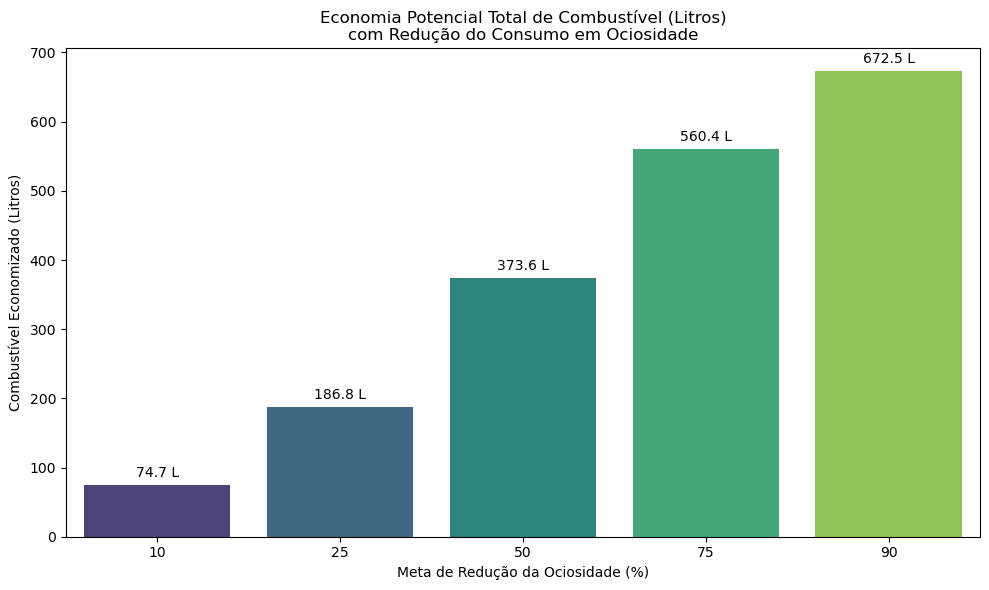

C:\Users\danie\AppData\Local\Temp\ipykernel_29128\3103250119.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp2 = sns.barplot(x='target_reduction_percent', y='saved_co2_kg', data=savings_df_overall, palette="viridis")


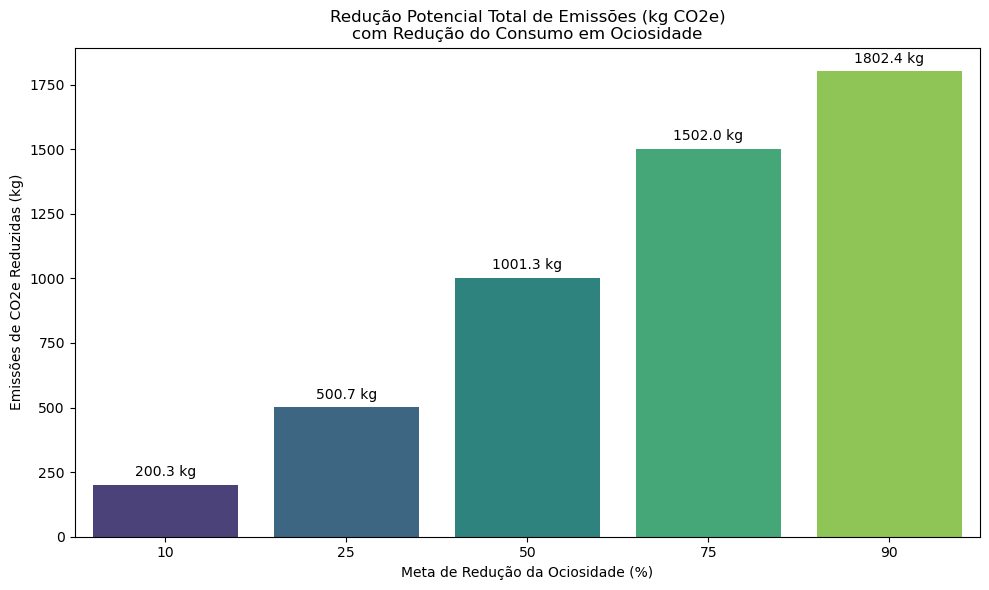

C:\Users\danie\AppData\Local\Temp\ipykernel_29128\3103250119.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp3 = sns.barplot(x='target_reduction_percent', y='saved_eur', data=savings_df_overall, palette="viridis") # Outra paleta padrão


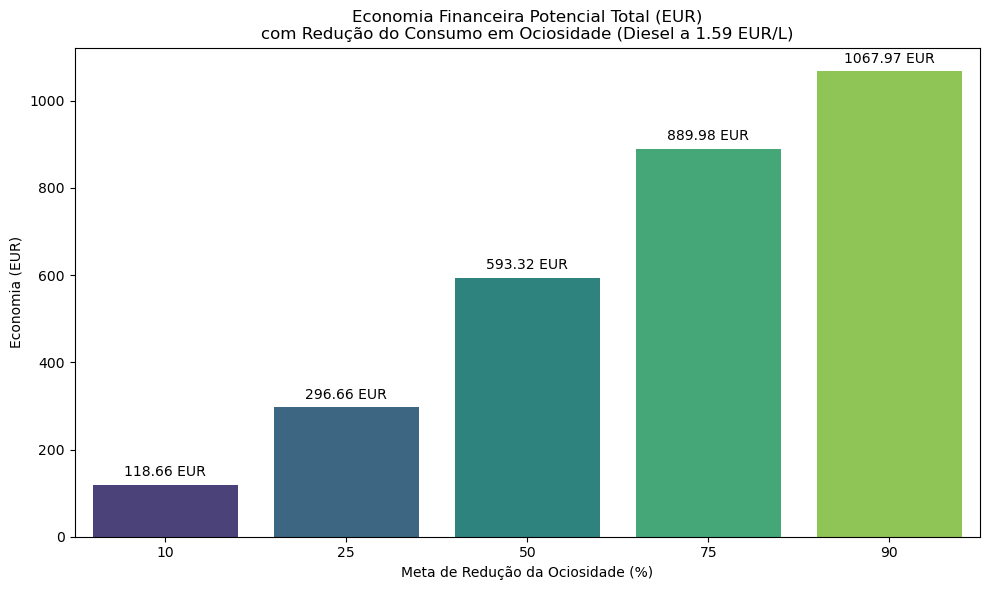

C:\Users\danie\AppData\Local\Temp\ipykernel_29128\3103250119.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


<Figure size 1400x800 with 0 Axes>

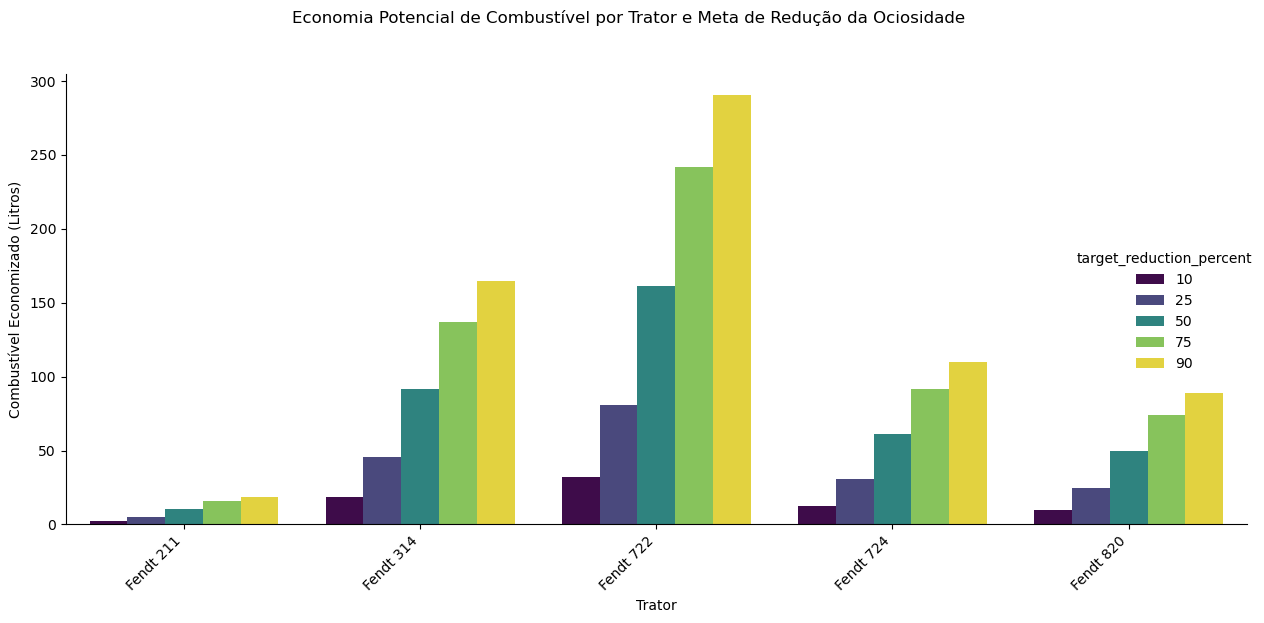


--- Célula 3 (v2) concluída ---


In [21]:
# Célula 3 (v2): Aprofundando Análise de Ociosidade e Potencial de Redução
# Com paletas de cores padronizadas e placeholder para preço do diesel

# Certifique-se de que a Célula 1 e a Célula 2 foram executadas.
# stats_df deve estar carregado e enriquecido com dados de ociosidade.
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np 
# import seaborn as sns # Já deve estar importado da Célula 1 do Notebook 02

print("--- Iniciando Célula 3 (v2): Aprofundando Análise de Ociosidade ---")

if 'stats_df' not in locals() or stats_df.empty:
    print("ERRO: DataFrame 'stats_df' não encontrado ou está vazio.")
    print("Execute as Células 1 e 2 primeiro.")
else:
    print("Usando 'stats_df' com informações de ociosidade.")
    # Garante que as colunas necessárias existem e são numéricas
    cols_to_check_and_fill = ['idle_fuel_liters', 'idle_hours', 'total_liters_consumed', 'total_hours_operational']
    for col in cols_to_check_and_fill:
        if col not in stats_df.columns:
            print(f"AVISO: Coluna '{col}' não encontrada em stats_df. Adicionando como zero.")
            stats_df[col] = 0
        else:
            stats_df[col] = pd.to_numeric(stats_df[col], errors='coerce').fillna(0)

    # --- Ponto 1: Calcular tempo total de operação em dias ---
    total_overall_hours = stats_df['total_hours_operational'].sum()
    DIAS_JORNADA_8_HORAS = total_overall_hours / 8.0
    print(f"\nTempo total de operação registrado (todos os tratores): {total_overall_hours:.2f} horas")
    print(f"Isso equivale a aproximadamente: {DIAS_JORNADA_8_HORAS:.2f} dias de operação (jornada de 8h/dia)")

    # --- Ponto 2: Adicionar novas metas de redução de ociosidade ---
    reduction_targets_percent = [10, 25, 50, 75, 90] 
    
    CO2_PER_LITER_DIESEL = 2.68 # kg CO2e / L
    
    # !!! AJUSTE ESTE VALOR QUANDO TIVER O PREÇO CORRETO !!!
    PRECO_DIESEL_EUR_POR_LITRO = 1.588 # Placeholder em EUR
    print(f"\nPREÇO DO DIESEL (PLACEHOLDER): {PRECO_DIESEL_EUR_POR_LITRO:.2f} EUR/L (AJUSTE ESTE VALOR!)")


    print(f"\nNovas metas de redução do combustível consumido em ociosidade: {reduction_targets_percent}%")
    print(f"  (Nota: 90% representa um potencial teórico com AP avançada)")
    print(f"Fator de emissão: {CO2_PER_LITER_DIESEL} kg CO2e/L de diesel")

    total_idle_fuel_overall = stats_df['idle_fuel_liters'].sum()
    total_idle_hours_overall = stats_df['idle_hours'].sum()
    
    print(f"\nDados gerais de ociosidade (todos os tratores/atividades):")
    print(f"  - Total de horas em ociosidade: {total_idle_hours_overall:.2f} h")
    print(f"  - Total de combustível consumido em ociosidade: {total_idle_fuel_overall:.2f} L")
    custo_total_ociosidade_eur = total_idle_fuel_overall * PRECO_DIESEL_EUR_POR_LITRO
    print(f"  - Custo estimado do combustível consumido em ociosidade: {custo_total_ociosidade_eur:.2f} EUR")


    potential_savings_overall = []
    for target_percent in reduction_targets_percent:
        reduction_decimal = target_percent / 100.0
        saved_fuel = total_idle_fuel_overall * reduction_decimal
        saved_co2 = saved_fuel * CO2_PER_LITER_DIESEL
        saved_eur = saved_fuel * PRECO_DIESEL_EUR_POR_LITRO # Cálculo do custo economizado
        potential_savings_overall.append({
            'target_reduction_percent': target_percent,
            'saved_fuel_liters': saved_fuel,
            'saved_co2_kg': saved_co2,
            'saved_eur': saved_eur
        })
        print(f"  Com redução de {target_percent}% da ociosidade:")
        print(f"    - Economia de combustível: {saved_fuel:.2f} L")
        print(f"    - Redução de emissões: {saved_co2:.2f} kg CO2e")
        print(f"    - Economia financeira: {saved_eur:.2f} EUR")


    savings_df_overall = pd.DataFrame(potential_savings_overall)

    # Calcular economias por trator com as novas metas
    idle_summary_by_tractor = stats_df.groupby('tractor', observed=True).agg(
        total_idle_fuel_liters_tractor=pd.NamedAgg(column='idle_fuel_liters', aggfunc='sum')
    ).reset_index()

    list_savings_by_tractor = []
    for target_percent in reduction_targets_percent:
        reduction_decimal = target_percent / 100.0
        for index, row in idle_summary_by_tractor.iterrows():
            tractor = row['tractor']
            saved_fuel_tractor = row['total_idle_fuel_liters_tractor'] * reduction_decimal
            saved_co2_tractor = saved_fuel_tractor * CO2_PER_LITER_DIESEL
            saved_eur_tractor = saved_fuel_tractor * PRECO_DIESEL_EUR_POR_LITRO
            list_savings_by_tractor.append({
                'tractor': tractor,
                'target_reduction_percent': target_percent,
                'saved_fuel_liters_tractor': saved_fuel_tractor,
                'saved_co2_kg_tractor': saved_co2_tractor,
                'saved_eur_tractor': saved_eur_tractor
            })
    
    savings_df_by_tractor = pd.DataFrame(list_savings_by_tractor)
    print("\nAmostra de economias potenciais por trator (para meta de 10%):")
    print(savings_df_by_tractor[savings_df_by_tractor['target_reduction_percent'] == 10].head())

    # --- Visualizar Economias Potenciais com Novas Metas e Paletas Padronizadas ---
    
    # Gráfico de Economia Total de Combustível
    if not savings_df_overall.empty:
        plt.figure(figsize=(10, 6))
        bp1 = sns.barplot(x='target_reduction_percent', y='saved_fuel_liters', data=savings_df_overall, palette="viridis")
        plt.title('Economia Potencial Total de Combustível (Litros)\ncom Redução do Consumo em Ociosidade')
        plt.xlabel('Meta de Redução da Ociosidade (%)')
        plt.ylabel('Combustível Economizado (Litros)')
        for bar in bp1.patches:
             bp1.annotate(f"{bar.get_height():.1f} L", 
                           (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                           ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
        plt.tight_layout()
        plt.show()

        # Gráfico de Redução Total de Emissões de CO2
        plt.figure(figsize=(10, 6))
        bp2 = sns.barplot(x='target_reduction_percent', y='saved_co2_kg', data=savings_df_overall, palette="viridis")
        plt.title('Redução Potencial Total de Emissões (kg CO2e)\ncom Redução do Consumo em Ociosidade')
        plt.xlabel('Meta de Redução da Ociosidade (%)')
        plt.ylabel('Emissões de CO2e Reduzidas (kg)')
        for bar in bp2.patches:
             bp2.annotate(f"{bar.get_height():.1f} kg", 
                           (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                           ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
        plt.tight_layout()
        plt.show()

        # Gráfico de Economia Financeira Total
        plt.figure(figsize=(10, 6))
        bp3 = sns.barplot(x='target_reduction_percent', y='saved_eur', data=savings_df_overall, palette="viridis") # Outra paleta padrão
        plt.title(f'Economia Financeira Potencial Total (EUR)\ncom Redução do Consumo em Ociosidade (Diesel a {PRECO_DIESEL_EUR_POR_LITRO:.2f} EUR/L)')
        plt.xlabel('Meta de Redução da Ociosidade (%)')
        plt.ylabel('Economia (EUR)')
        for bar in bp3.patches:
             bp3.annotate(f"{bar.get_height():.2f} EUR", 
                           (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                           ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
        plt.tight_layout()
        plt.show()

    else:
        print("Não foi possível gerar gráficos de economia geral.")

    # Gráfico de Economia de Combustível por Trator para MÚLTIPLAS METAS
    if not savings_df_by_tractor.empty:
        plt.figure(figsize=(14, 8)) # Ajustado para melhor visualização
        g = sns.catplot(
            data=savings_df_by_tractor, 
            x='tractor', 
            y='saved_fuel_liters_tractor', 
            hue='target_reduction_percent', 
            kind='bar',
            palette='viridis', # Paleta padrão boa para categorias
            height=6, aspect=1.8,
            legend_out=True # Ajusta a legenda para fora se necessário
        )
        g.set_axis_labels("Trator", "Combustível Economizado (Litros)")
        g.fig.suptitle('Economia Potencial de Combustível por Trator e Meta de Redução da Ociosidade', y=1.03) # Título um pouco acima
        # Rotaciona os rótulos do eixo x para melhor legibilidade
        for ax in g.axes.flat: # Itera sobre os eixos do FacetGrid
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        plt.tight_layout() # Aplica tight_layout após ajustes
        plt.show()
    else:
        print(f"Não foi possível gerar gráfico de economia por trator com múltiplas metas.")

print("\n--- Célula 3 (v2) concluída ---")


--- Iniciando Célula 4 (v2): Custo da Ociosidade e Custo por Hora Ociosa ---
Usando 'stats_df' com informações de ociosidade e preço do diesel.
Preço do diesel considerado: 1.59 EUR/L

Coluna 'idle_cost_eur' recalculada/atualizada em stats_df.
Amostra de stats_df com custo da ociosidade:
     tractor               activity  idle_hours  idle_fuel_liters  \
0  Fendt 211                  Geral   12.030611         19.607974   
1  Fendt 211  Precision air seeding    0.462194          1.152874   
2  Fendt 314         Disc harrowing    0.276444          0.733811   
3  Fendt 314            Fertilizing    0.589889          1.877549   
4  Fendt 314                  Geral   68.459417        172.392141   

   idle_cost_eur  percent_idle_time  
0      31.137463          25.971015  
1       1.830765           8.873140  
2       1.165292           5.827653  
3       2.981547           6.447891  
4     273.758721          28.939554  

Custo Total da Ociosidade por Atividade (EUR):
activity
Geral      

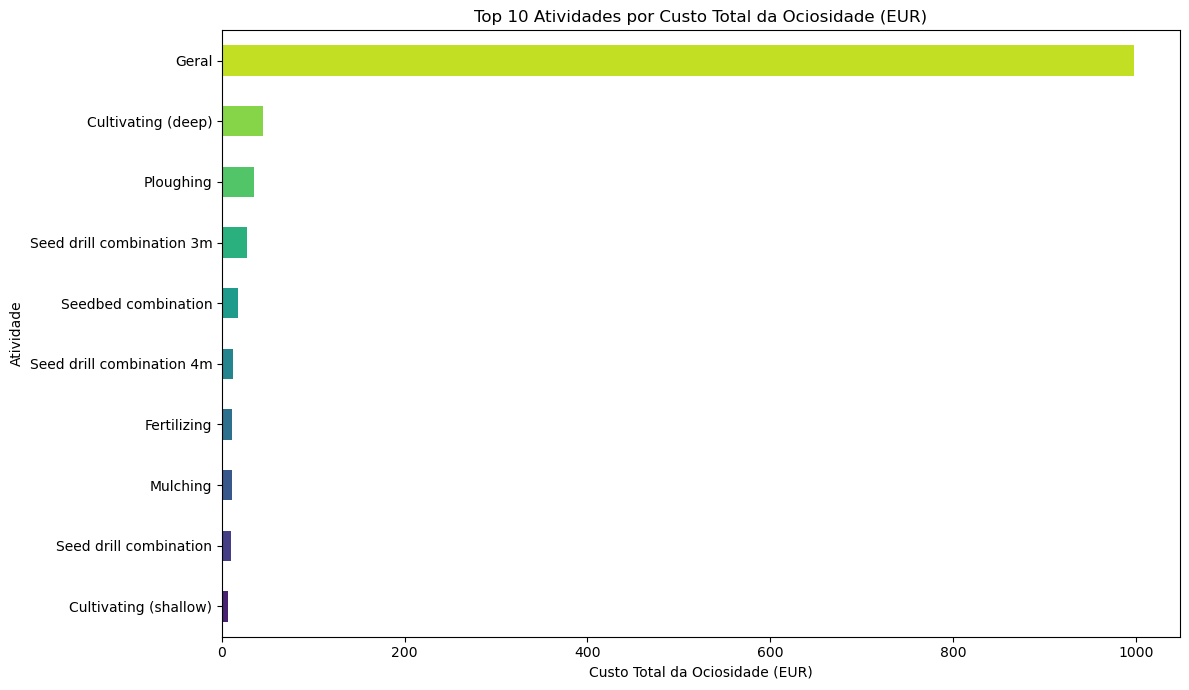


Percentual Médio de Tempo Ocioso por Atividade (para atividades com >1h total):
activity
Geral                        26.991254
Power harrowing              14.792161
Rotary tilling               14.030999
Fertilizing                  12.285798
Seedbed combination           9.758213
Seed drill combination 3m     9.391579
Precision air seeding         8.873140
Cultivating (deep)            8.003334
Ploughing                     7.479276
Seed drill combination 4m     7.207062
Name: percent_idle_time, dtype: float64


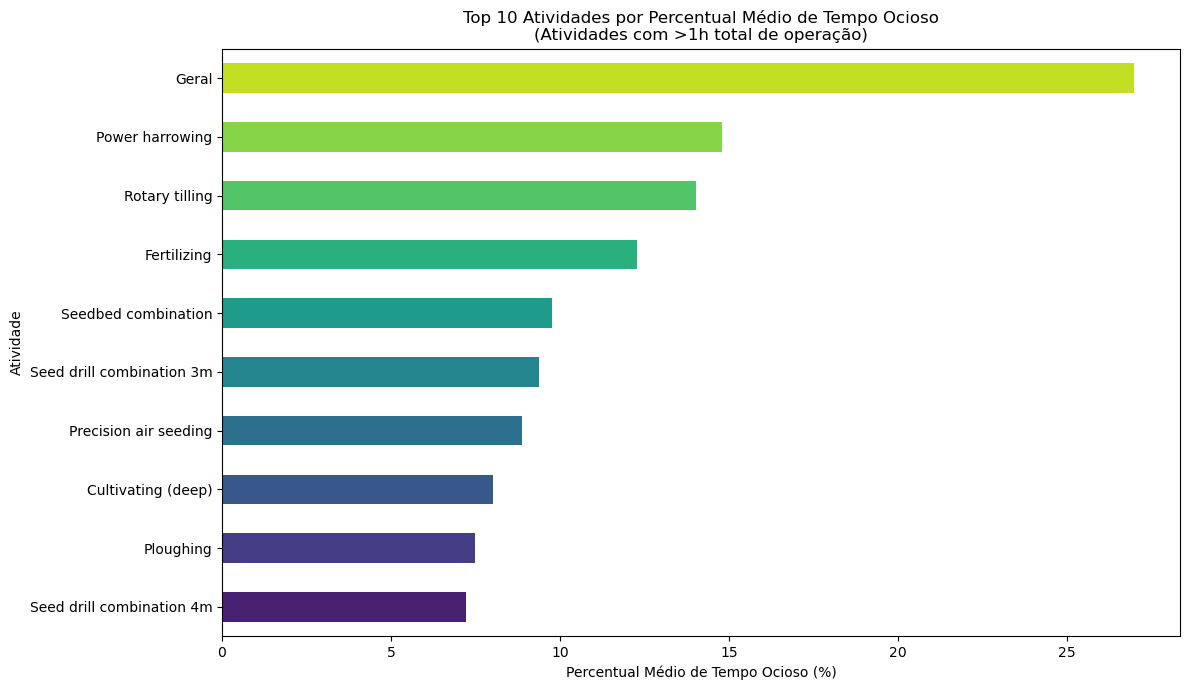


Custo Total da Ociosidade por Trator (EUR):
tractor
Fendt 722    512.142435
Fendt 314    290.351143
Fendt 724    194.311532
Fendt 820    156.860752
Fendt 211     32.968228
Name: idle_cost_eur, dtype: float64


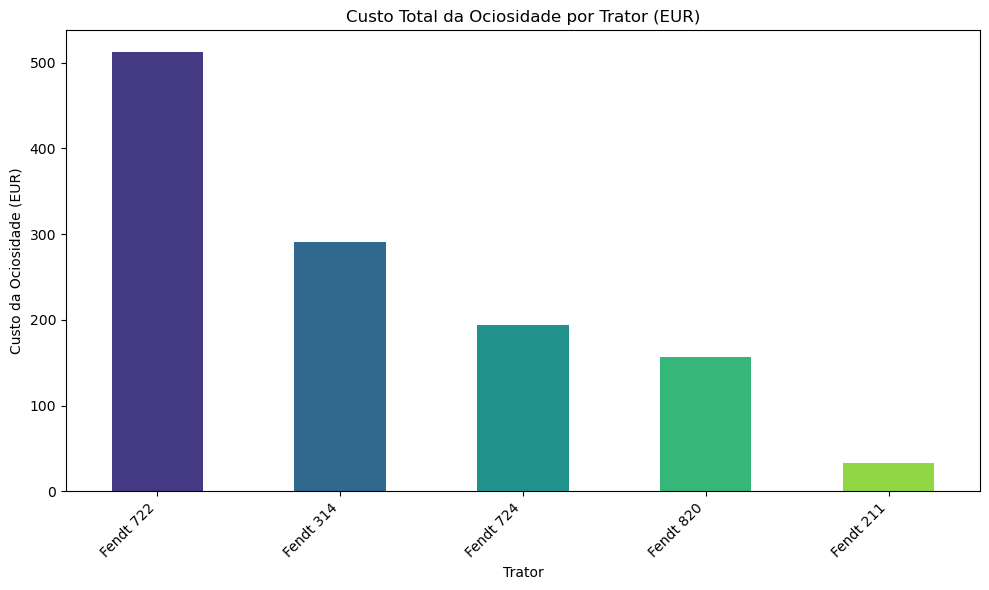


--- Análise do Custo por Hora Ociosa ---

Coluna 'idle_cost_per_idle_hour' adicionada a stats_df.
Amostra de stats_df com custo por hora ociosa:
     tractor               activity  idle_hours  idle_cost_eur  \
0  Fendt 211                  Geral   12.030611      31.137463   
1  Fendt 211  Precision air seeding    0.462194       1.830765   
2  Fendt 314         Disc harrowing    0.276444       1.165292   
3  Fendt 314            Fertilizing    0.589889       2.981547   
4  Fendt 314                  Geral   68.459417     273.758721   

   idle_cost_per_idle_hour  
0                 2.588186  
1                 3.961027  
2                 4.215284  
3                 5.054422  
4                 3.998847  

Descrição da coluna 'idle_cost_per_idle_hour':
count    33.000000
mean      5.057390
std       1.716051
min       0.000000
25%       4.514993
50%       5.149790
75%       6.129783
max       7.663540
Name: idle_cost_per_idle_hour, dtype: float64

Custo Médio Geral por Hora Ociosa (p

C:\Users\danie\AppData\Local\Temp\ipykernel_29128\1787507737.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data_cost_hr, x='activity', y='idle_cost_per_idle_hour', order=ordered_activities_cost_hr, palette="Spectral")


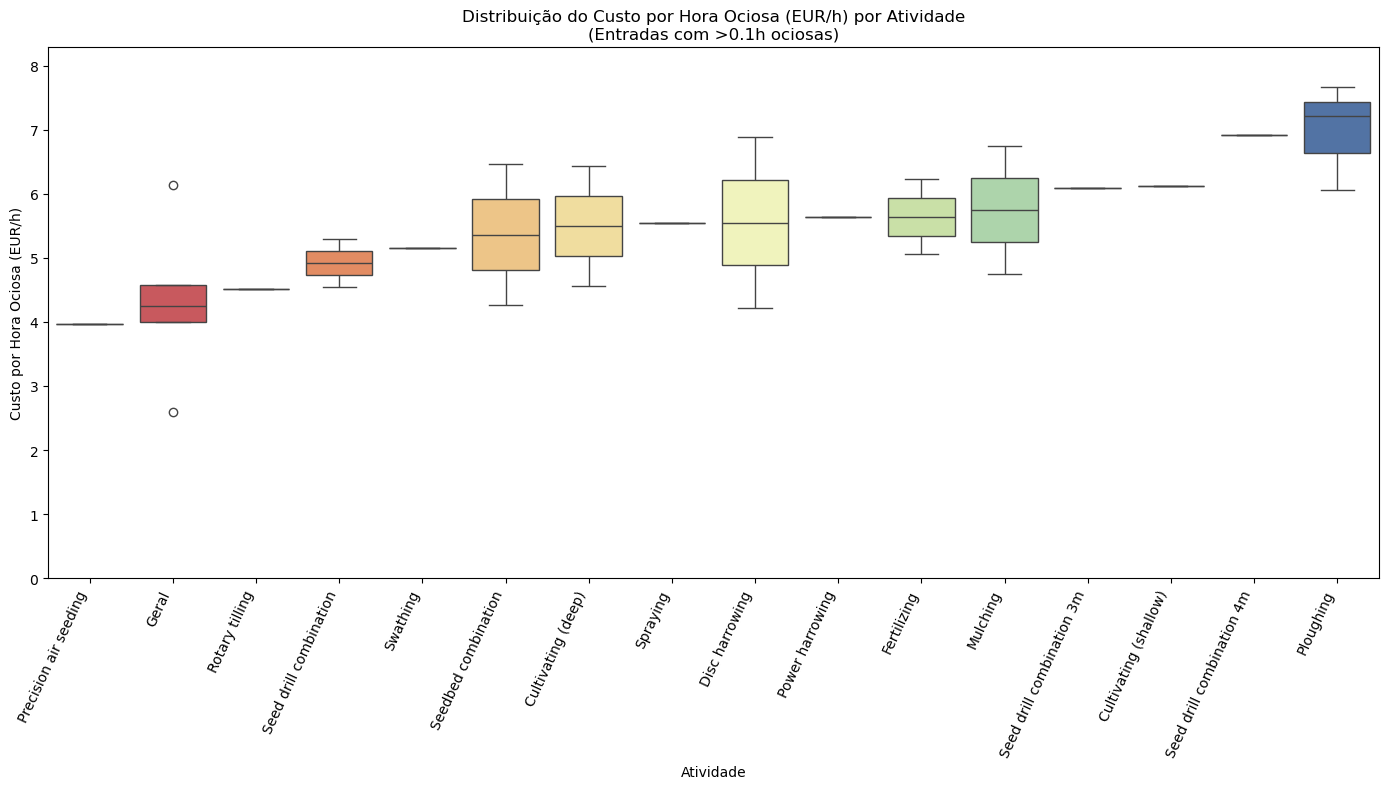


--- Célula 4 (v2) concluída ---


In [22]:
# Célula 4 (v2): Detalhamento do Custo da Ociosidade e Custo por Hora Ociosa

# Certifique-se de que as Células 1, 2 e 3 (v2) foram executadas.
# stats_df deve estar carregado e enriquecido com dados de ociosidade.
# PRECO_DIESEL_EUR_POR_LITRO deve estar definido (mesmo que placeholder).
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

print("--- Iniciando Célula 4 (v2): Custo da Ociosidade e Custo por Hora Ociosa ---")

if 'stats_df' not in locals() or stats_df.empty:
    print("ERRO: DataFrame 'stats_df' não encontrado ou está vazio.")
    print("Execute as Células 1, 2 e 3 (v2) primeiro.")
elif 'PRECO_DIESEL_EUR_POR_LITRO' not in globals(): # Verifica se a variável global existe
    print("ERRO: Variável 'PRECO_DIESEL_EUR_POR_LITRO' não definida.")
    print("Defina o preço do diesel na Célula 3 (v2) ou no início desta célula.")
else:
    print("Usando 'stats_df' com informações de ociosidade e preço do diesel.")
    print(f"Preço do diesel considerado: {PRECO_DIESEL_EUR_POR_LITRO:.2f} EUR/L")

    # --- 1. Calcular Custo da Ociosidade por Trator e Atividade (Revisão) ---
    if 'idle_fuel_liters' in stats_df.columns:
        if 'idle_cost_eur' not in stats_df.columns: # Calcula apenas se não existir
            stats_df['idle_cost_eur'] = stats_df['idle_fuel_liters'] * PRECO_DIESEL_EUR_POR_LITRO
            print("\nColuna 'idle_cost_eur' adicionada a stats_df.")
        else:
            # Recalcula para garantir que está usando o PRECO_DIESEL_EUR_POR_LITRO atual, se ele mudou
            stats_df['idle_cost_eur'] = stats_df['idle_fuel_liters'] * PRECO_DIESEL_EUR_POR_LITRO
            print("\nColuna 'idle_cost_eur' recalculada/atualizada em stats_df.")
        
        print("Amostra de stats_df com custo da ociosidade:")
        print(stats_df[['tractor', 'activity', 'idle_hours', 'idle_fuel_liters', 'idle_cost_eur', 'percent_idle_time']].head())
    else:
        print("ERRO: Coluna 'idle_fuel_liters' não encontrada em stats_df. Não foi possível calcular o custo da ociosidade.")
        stats_df['idle_cost_eur'] = 0 

    # --- 2. Análise Detalhada por Atividade (Existente) ---

    # A. Atividades com Maior Custo Total de Ociosidade
    if 'idle_cost_eur' in stats_df.columns and stats_df['idle_cost_eur'].sum() > 0:
        activity_idle_cost_sum = stats_df.groupby('activity', observed=True)['idle_cost_eur'].sum().sort_values(ascending=False)
        print("\nCusto Total da Ociosidade por Atividade (EUR):")
        print(activity_idle_cost_sum.head(10)) 

        if not activity_idle_cost_sum.empty:
            plt.figure(figsize=(12, 7))
            activity_idle_cost_sum.nlargest(10).sort_values(ascending=True).plot(kind='barh', color=sns.color_palette("viridis", n_colors=10))
            plt.title('Top 10 Atividades por Custo Total da Ociosidade (EUR)')
            plt.xlabel('Custo Total da Ociosidade (EUR)')
            plt.ylabel('Atividade')
            plt.tight_layout()
            plt.show()
    elif 'idle_cost_eur' in stats_df.columns:
        print("Nenhum custo de ociosidade registrado para plotar por atividade.")
    else:
        print("Coluna 'idle_cost_eur' não disponível para análise de custo por atividade.")

    # B. Atividades com Maior Percentual Médio de Tempo Ocioso
    if 'percent_idle_time' in stats_df.columns and 'total_hours_operational' in stats_df.columns:
        stats_relevant_activities = stats_df[stats_df['total_hours_operational'] > 1.0] 
        
        if not stats_relevant_activities.empty:
            activity_percent_idle_mean = stats_relevant_activities.groupby('activity', observed=True)['percent_idle_time'].mean().sort_values(ascending=False)
            print("\nPercentual Médio de Tempo Ocioso por Atividade (para atividades com >1h total):")
            print(activity_percent_idle_mean.head(10))

            if not activity_percent_idle_mean.empty:
                plt.figure(figsize=(12, 7))
                activity_percent_idle_mean.nlargest(10).sort_values(ascending=True).plot(kind='barh', color=sns.color_palette("viridis", n_colors=10))
                plt.title('Top 10 Atividades por Percentual Médio de Tempo Ocioso\n(Atividades com >1h total de operação)')
                plt.xlabel('Percentual Médio de Tempo Ocioso (%)')
                plt.ylabel('Atividade')
                plt.tight_layout()
                plt.show()
        else:
            print("Nenhuma atividade com mais de 1h total de operação encontrada para análise de percentual de tempo ocioso.")
    else:
        print("Colunas 'percent_idle_time' ou 'total_hours_operational' não disponíveis para análise de percentual de tempo ocioso por atividade.")
        
    # C. Custo da Ociosidade por Trator
    if 'idle_cost_eur' in stats_df.columns and stats_df['idle_cost_eur'].sum() > 0:
        tractor_idle_cost_sum = stats_df.groupby('tractor', observed=True)['idle_cost_eur'].sum().sort_values(ascending=False)
        print("\nCusto Total da Ociosidade por Trator (EUR):")
        print(tractor_idle_cost_sum)

        if not tractor_idle_cost_sum.empty:
            plt.figure(figsize=(10, 6))
            tractor_idle_cost_sum.plot(kind='bar', color=sns.color_palette("viridis", n_colors=len(tractor_idle_cost_sum)))
            plt.title('Custo Total da Ociosidade por Trator (EUR)')
            plt.ylabel('Custo da Ociosidade (EUR)')
            plt.xlabel('Trator')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
    elif 'idle_cost_eur' in stats_df.columns:
        print("Nenhum custo de ociosidade registrado para plotar por trator.")


    # --- 3. NOVA ANÁLISE: Custo da Ociosidade por Hora Ociosa ---
    print("\n--- Análise do Custo por Hora Ociosa ---")
    if 'idle_cost_eur' in stats_df.columns and 'idle_hours' in stats_df.columns:
        # Calcula o custo por hora ociosa, tratando divisão por zero
        stats_df['idle_cost_per_idle_hour'] = stats_df.apply(
            lambda row: row['idle_cost_eur'] / row['idle_hours'] if row['idle_hours'] > 1e-6 else 0, # Evita divisão por zero ou por valores muito pequenos
            axis=1
        )
        print("\nColuna 'idle_cost_per_idle_hour' adicionada a stats_df.")
        print("Amostra de stats_df com custo por hora ociosa:")
        print(stats_df[['tractor', 'activity', 'idle_hours', 'idle_cost_eur', 'idle_cost_per_idle_hour']].head())

        print("\nDescrição da coluna 'idle_cost_per_idle_hour':")
        print(stats_df['idle_cost_per_idle_hour'].describe())

        # A. Custo Médio por Hora Ociosa - Geral
        # Filtra para evitar distorções por entradas com pouquíssimas horas ociosas
        relevant_for_avg_cost_per_hour = stats_df[stats_df['idle_hours'] > 0.1] # Pelo menos ~6 minutos de ociosidade
        if not relevant_for_avg_cost_per_hour.empty:
            overall_avg_idle_cost_per_hour = (relevant_for_avg_cost_per_hour['idle_cost_eur'].sum() / 
                                              relevant_for_avg_cost_per_hour['idle_hours'].sum())
            print(f"\nCusto Médio Geral por Hora Ociosa (para entradas com >0.1h ociosas): {overall_avg_idle_cost_per_hour:.2f} EUR/h")
        else:
            print("\nNão há dados suficientes para calcular o custo médio geral por hora ociosa.")


        # B. Visualização: Custo por Hora Ociosa por Atividade (Boxplot)
        if not relevant_for_avg_cost_per_hour.empty:
            # Considerar apenas atividades com um número razoável de ocorrências ou horas
            activity_counts_cost_hr = relevant_for_avg_cost_per_hour['activity'].value_counts()
            common_activities_cost_hr = activity_counts_cost_hr[activity_counts_cost_hr >= 1].index 
            
            if not common_activities_cost_hr.empty:
                plot_data_cost_hr = relevant_for_avg_cost_per_hour[relevant_for_avg_cost_per_hour['activity'].isin(common_activities_cost_hr)]
                if not plot_data_cost_hr.empty:
                    plt.figure(figsize=(14, 8))
                    ordered_activities_cost_hr = plot_data_cost_hr.groupby('activity')['idle_cost_per_idle_hour'].median().sort_values().index
                    sns.boxplot(data=plot_data_cost_hr, x='activity', y='idle_cost_per_idle_hour', order=ordered_activities_cost_hr, palette="Spectral")
                    plt.title('Distribuição do Custo por Hora Ociosa (EUR/h) por Atividade\n(Entradas com >0.1h ociosas)')
                    plt.ylabel('Custo por Hora Ociosa (EUR/h)')
                    plt.xlabel('Atividade')
                    plt.xticks(rotation=65, ha='right')
                    min_y_cph = 0
                    max_y_cph_val = plot_data_cost_hr['idle_cost_per_idle_hour'].quantile(0.99)
                    max_y_cph = max(5, max_y_cph_val * 1.1) if pd.notnull(max_y_cph_val) else 5 # Limite mínimo de 5 EUR/h no gráfico
                    plt.ylim(min_y_cph, max_y_cph)
                    plt.tight_layout()
                    plt.show()
                else:
                    print("Não há dados suficientes para o boxplot de custo por hora ociosa por atividade após filtragem.")
            else:
                print("Não há atividades comuns suficientes para o boxplot de custo por hora ociosa.")
        else:
            print("Não há dados suficientes (idle_hours > 0.1) para analisar o custo por hora ociosa por atividade.")
            
    else:
        print("Colunas 'idle_cost_eur' ou 'idle_hours' não disponíveis para análise de custo por hora ociosa.")

    # --- 4. Discussão sobre a categoria "Geral" (Existente) ---
    # ... (mantém a discussão anterior)
    
    # --- 5. Extrapolação para Área (Discussão para o trabalho - Existente) ---
    # ... (mantém a discussão anterior)

print("\n--- Célula 4 (v2) concluída ---")


In [24]:
# Célula 5 (v2): Síntese dos Resultados e Métricas Chave para ConBAP
# (Considerando limiar de velocidade de 0.75 m/s e preço do diesel de 1.588 EUR/L)

# Certifique-se de que as Células 1, 2 (com VELOCIDADE_MAX_OCIOSO_MS = 0.75), 
# Célula 3 (v2 - com PRECO_DIESEL_EUR_POR_LITRO = 1.588 e reexecutada), 
# e Célula 4 (v2 - reexecutada após Célula 3) foram completadas.

# DataFrames necessários: stats_df, savings_df_overall, savings_df_by_tractor
# Variáveis necessárias: total_overall_hours, DIAS_JORNADA_8_HORAS, 
#                       total_idle_hours_overall, total_idle_fuel_overall, custo_total_ociosidade_eur,
#                       PRECO_DIESEL_EUR_POR_LITRO, CO2_PER_LITER_DIESEL
import pandas as pd
# As importações de matplotlib e seaborn já devem ter sido feitas na Célula 1.

print("--- Iniciando Célula 5 (v2): Síntese dos Resultados para ConBAP ---")
print("Certifique-se de que as Células 2, 3 e 4 foram reexecutadas com os últimos parâmetros (velocidade ociosa = 0.75 m/s, preço diesel = 1.588 EUR/L).")

# Verifica se as variáveis e DataFrames principais existem
required_vars = ['stats_df', 'savings_df_overall', 'savings_df_by_tractor', 
                 'total_overall_hours', 'DIAS_JORNADA_8_HORAS', 
                 'total_idle_hours_overall', 'total_idle_fuel_overall', 
                 'custo_total_ociosidade_eur', 'PRECO_DIESEL_EUR_POR_LITRO', 'CO2_PER_LITER_DIESEL']
missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]

if missing_vars:
    print(f"ERRO: As seguintes variáveis/DataFrames não foram encontradas: {', '.join(missing_vars)}")
    print("Por favor, execute as Células 1, 2, 3 (v2) e 4 (v2) primeiro com os parâmetros corretos.")
else:
    print("Todas as variáveis e DataFrames necessários foram encontrados. Gerando resumo...\n")

    # --- A. Resumo das Principais Métricas Globais ---
    print("="*60)
    print("  RESUMO DAS MÉTRICAS GLOBAIS (Limiar Ocioso <= 0.75 m/s)")
    print("="*60)
    print(f"1. Período de Coleta de Dados (Equivalente):")
    print(f"   - Total de Horas de Operação Registradas: {total_overall_hours:.2f} horas")
    print(f"   - Equivalente a Dias de Operação (jornada 8h): {DIAS_JORNADA_8_HORAS:.2f} dias")
    
    print(f"\n2. Ociosidade Identificada (Velocidade <= {stats_df.attrs.get('VELOCIDADE_MAX_OCIOSO_MS_USADA', '0.75')} m/s):") # Tenta pegar o valor usado
    if total_overall_hours > 0:
        percent_total_idle_time = (total_idle_hours_overall / total_overall_hours) * 100
        print(f"   - Total de Horas em Ociosidade: {total_idle_hours_overall:.2f} h ({percent_total_idle_time:.2f}% do total de horas operacionais)")
    else:
        print(f"   - Total de Horas em Ociosidade: {total_idle_hours_overall:.2f} h (Percentual não calculado)")
        
    print(f"   - Total de Combustível Consumido em Ociosidade: {total_idle_fuel_overall:.2f} L")
    # Recalcula o custo total da ociosidade com o preço correto para garantir consistência no resumo
    custo_total_ociosidade_eur_recalc = total_idle_fuel_overall * PRECO_DIESEL_EUR_POR_LITRO
    print(f"   - Custo Estimado do Combustível em Ociosidade: {custo_total_ociosidade_eur_recalc:.2f} EUR (Diesel a {PRECO_DIESEL_EUR_POR_LITRO:.3f} EUR/L)")
    
    if total_idle_hours_overall > 0:
        avg_cost_per_idle_hour_overall = custo_total_ociosidade_eur_recalc / total_idle_hours_overall
        print(f"   - Custo Médio de 1 Hora Ociosa: {avg_cost_per_idle_hour_overall:.2f} EUR/h")
    else:
        print(f"   - Custo Médio de 1 Hora Ociosa: N/A (sem horas ociosas)")

    # --- B. Impacto Potencial da Redução da Ociosidade ---
    print("\n" + "="*60)
    print("  IMPACTO POTENCIAL DA REDUÇÃO DO CONSUMO EM OCIOSIDADE")
    print("="*60)
    metas_resumo = [25, 50, 75, 90] # Focando nas metas mais impactantes para o resumo
    for _, row in savings_df_overall[savings_df_overall['target_reduction_percent'].isin(metas_resumo)].iterrows():
        # Recalcula a economia financeira com o preço correto para este resumo
        saved_eur_recalc = row['saved_fuel_liters'] * PRECO_DIESEL_EUR_POR_LITRO
        print(f"\n  Com Redução de {row['target_reduction_percent']:.0f}% do Consumo em Ociosidade:")
        print(f"    - Economia de Combustível: {row['saved_fuel_liters']:.2f} L")
        print(f"    - Redução de Emissões CO2e: {row['saved_co2_kg']:.2f} kg")
        print(f"    - Economia Financeira: {saved_eur_recalc:.2f} EUR")

    # --- C. Destaques por Trator e Atividade ---
    print("\n" + "="*60)
    print("  DESTAQUES POR TRATOR E ATIVIDADE (Ociosidade <= 0.75 m/s)")
    print("="*60)

    if 'idle_cost_eur' in stats_df.columns and not stats_df.empty:
        # Recalcula idle_cost_eur em stats_df para este resumo, caso não tenha sido atualizado
        stats_df_copy = stats_df.copy() # Trabalha com uma cópia para não alterar o stats_df original inesperadamente
        stats_df_copy['idle_cost_eur_recalc'] = stats_df_copy['idle_fuel_liters'] * PRECO_DIESEL_EUR_POR_LITRO

        top_tractors_idle_cost = stats_df_copy.sort_values(by='idle_cost_eur_recalc', ascending=False).head(3)
        print("\n  Top 3 Tratores por Custo Total de Ociosidade (EUR):")
        for index, row_tractor in top_tractors_idle_cost.iterrows():
            print(f"    - {row_tractor['tractor']}: {row_tractor['idle_cost_eur_recalc']:.2f} EUR (com {row_tractor['idle_hours']:.2f}h ociosas)")
    
        activity_idle_cost_sum = stats_df_copy.groupby('activity', observed=True)['idle_cost_eur_recalc'].sum().sort_values(ascending=False).head(3)
        print("\n  Top 3 Atividades por Custo Total de Ociosidade (EUR):")
        for activity, cost in activity_idle_cost_sum.items():
            print(f"    - {activity}: {cost:.2f} EUR")

        if 'percent_idle_time' in stats_df_copy.columns:
            activity_percent_idle_mean = stats_df_copy[stats_df_copy['total_hours_operational'] > 1.0].groupby('activity', observed=True)['percent_idle_time'].mean().sort_values(ascending=False).head(3)
            print("\n  Top 3 Atividades por Percentual Médio de Tempo Ocioso (>1h de operação total):")
            for activity, perc in activity_percent_idle_mean.items():
                print(f"    - {activity}: {perc:.2f}%")
    else:
        print("\n  Dados de custo de ociosidade não disponíveis em stats_df para destaques.")

    # --- D. Notas para o Trabalho do ConBAP ---
    print("\n" + "="*60)
    print("  NOTAS E CONSIDERAÇÕES PARA O TRABALHO (ConBAP)")
    print("="*60)
    print(f"1. Limiares de Ociosidade: Critérios utilizados: Velocidade <= {stats_df.attrs.get('VELOCIDADE_MAX_OCIOSO_MS_USADA', '0.75')} m/s, RPM entre {stats_df.attrs.get('RPM_MIN_OCIOSO_USADO', '700')}-{stats_df.attrs.get('RPM_MAX_OCIOSO_USADO', '1000')}, Taxa de Combustível > {stats_df.attrs.get('FUEL_RATE_MIN_OCIOSO_L_H_USADO', '0.1')} L/h.")
    print(f"2. Preço do Diesel: Utilizado o valor de {PRECO_DIESEL_EUR_POR_LITRO:.3f} EUR/L (média Alemanha, 2024).")
    print("3. Atividade 'Geral': Consistentemente a maior fonte de ociosidade. Discutir causas (manobras, esperas, transições) e potencial de otimização com AP.")
    print("4. Impacto da Redução de Ociosidade: Os resultados demonstram potencial significativo para economia de combustível, redução de emissões e ganhos financeiros.")
    print("5. Extrapolação e Impacto em Larga Escala: Para o ConBAP, enfatizar que a aplicação dessas otimizações em uma frota maior teria um impacto ambiental e econômico consideravelmente ampliado. Mencionar a necessidade de dados adicionais (área, frota) para quantificar essa extrapolação de forma robusta.")
    print("6. Gráficos Chave para Pôster/Resumo: (Conforme gerados nas Células 3 e 4 com os parâmetros atualizados)")
    print("   - Economia Potencial Total de Combustível (Litros) vs. Metas de Redução.")
    print("   - Redução Potencial Total de Emissões (kg CO2e) vs. Metas de Redução.")
    print("   - Economia Financeira Potencial Total (EUR) vs. Metas de Redução.")
    print("   - (Opcional) Custo Total da Ociosidade por Atividade (Top 5-10).")
    print("   - (Opcional) Percentual Médio de Tempo Ocioso por Atividade (Top 5-10).")
    print("   - (Opcional) Economia Potencial de Combustível por Trator para diferentes metas.")

    # Adicionando um atributo ao stats_df para registrar os parâmetros de ociosidade usados.
    # Isso é útil se você quiser salvar stats_df e lembrar quais parâmetros geraram esses resultados.
    stats_df.attrs['VELOCIDADE_MAX_OCIOSO_MS_USADA'] = VELOCIDADE_MAX_OCIOSO_MS if 'VELOCIDADE_MAX_OCIOSO_MS' in locals() else 'Não definido nesta execução de C5'
    stats_df.attrs['RPM_MIN_OCIOSO_USADO'] = RPM_MIN_OCIOSO if 'RPM_MIN_OCIOSO' in locals() else 'Não definido'
    stats_df.attrs['RPM_MAX_OCIOSO_USADO'] = RPM_MAX_OCIOSO if 'RPM_MAX_OCIOSO' in locals() else 'Não definido'
    stats_df.attrs['FUEL_RATE_MIN_OCIOSO_L_H_USADO'] = FUEL_RATE_MIN_OCIOSO_L_H if 'FUEL_RATE_MIN_OCIOSO_L_H' in locals() else 'Não definido'


print("\n--- Célula 5 (v2) concluída ---")


--- Iniciando Célula 5 (v2): Síntese dos Resultados para ConBAP ---
Certifique-se de que as Células 2, 3 e 4 foram reexecutadas com os últimos parâmetros (velocidade ociosa = 0.75 m/s, preço diesel = 1.588 EUR/L).
Todas as variáveis e DataFrames necessários foram encontrados. Gerando resumo...

  RESUMO DAS MÉTRICAS GLOBAIS (Limiar Ocioso <= 0.75 m/s)
1. Período de Coleta de Dados (Equivalente):
   - Total de Horas de Operação Registradas: 1363.01 horas
   - Equivalente a Dias de Operação (jornada 8h): 170.38 dias

2. Ociosidade Identificada (Velocidade <= 0.75 m/s):
   - Total de Horas em Ociosidade: 245.53 h (18.01% do total de horas operacionais)
   - Total de Combustível Consumido em Ociosidade: 747.25 L
   - Custo Estimado do Combustível em Ociosidade: 1186.63 EUR (Diesel a 1.588 EUR/L)
   - Custo Médio de 1 Hora Ociosa: 4.83 EUR/h

  IMPACTO POTENCIAL DA REDUÇÃO DO CONSUMO EM OCIOSIDADE

  Com Redução de 25% do Consumo em Ociosidade:
    - Economia de Combustível: 186.81 L
    - 